<a href="https://colab.research.google.com/github/SydneySmoke/BME3053C-Spring-2025/blob/main/Homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
anscombe_df = pd.read_json('/content/sample_data/anscombe.json')

Columns in dataset: Index(['Series', 'X', 'Y'], dtype='object')
           X                                               Y            \
       count mean       std  min  25%  50%   75%   max count      mean   
Series                                                                   
I       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
II      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III     11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV      11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                  
             std   min    25%   50%   75%    max  
Series                                            
I       2.032890  4.26  6.315  7.58  8.57  10.84  
II      2.031657  3.10  6.695  8.14  8.95   9.26  
III     2.030424  5.39  6.250  7.11  7.98  12.74  
IV      2.030579  5.25  6.170  7.04  8.19  12.50  


<ipython-input-23-4d2d4f3302fa>:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(x_data, labels=datasets)
<ipython-input-23-4d2d4f3302fa>:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(y_data, labels=datasets)


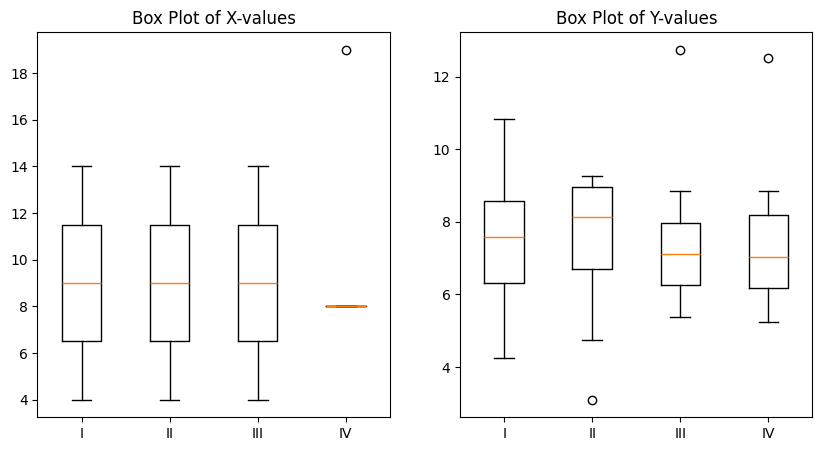

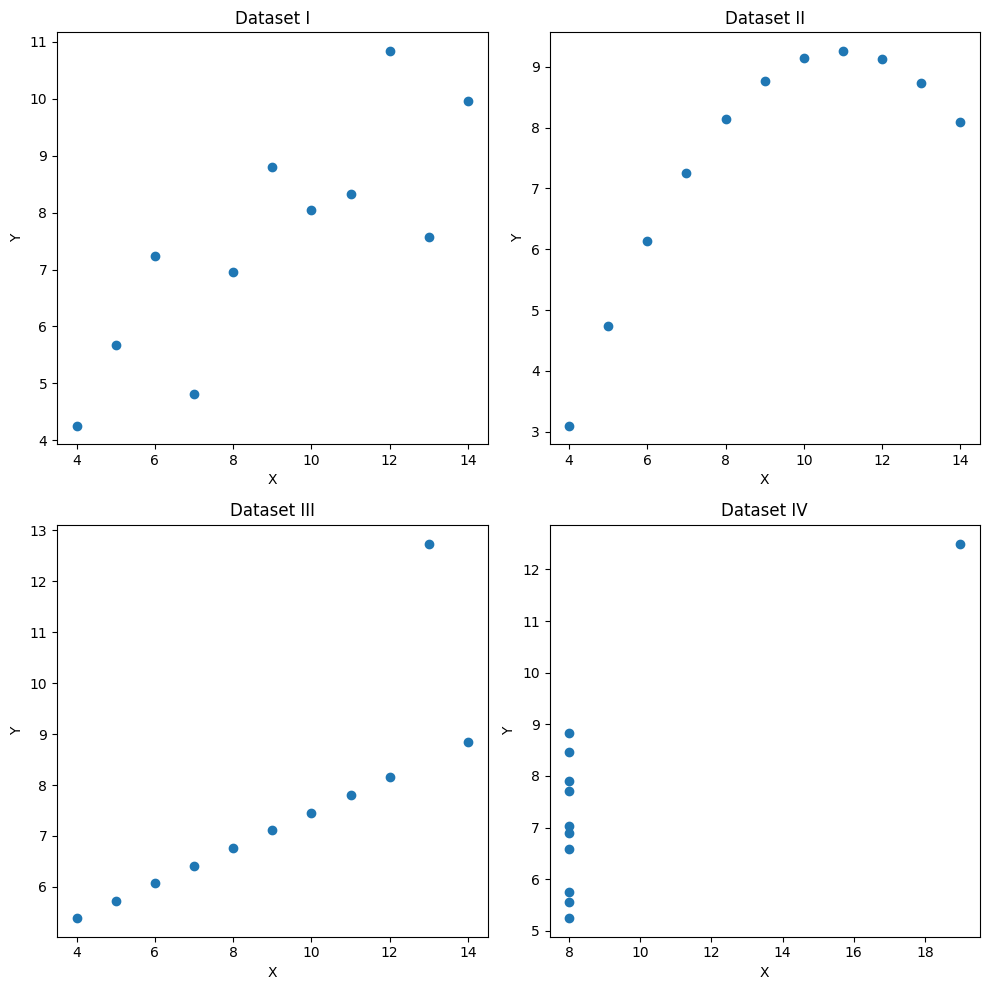

In [23]:
print("Columns in dataset:", anscombe_df.columns)

# Ensure correct column names
if 'Series' not in anscombe_df.columns:
    raise KeyError("Column 'Series' not found in dataset. Check column names.")

# Group by 'Series'
grouped_df = anscombe_df.groupby('Series')

# Display summary statistics
print(grouped_df.describe())

# Box plots for x and y values
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

datasets = sorted(grouped_df.groups.keys())  # Sorting dataset names
x_data = [grouped_df.get_group(d)['X'] for d in datasets]
y_data = [grouped_df.get_group(d)['Y'] for d in datasets]

axes[0].boxplot(x_data, labels=datasets)
axes[0].set_title('Box Plot of X-values')

axes[1].boxplot(y_data, labels=datasets)
axes[1].set_title('Box Plot of Y-values')

plt.show()

# Scatter plots for each dataset
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i, dataset in enumerate(datasets):
    data = grouped_df.get_group(dataset)
    ax = axes[i // 2, i % 2]
    ax.scatter(data['X'], data['Y'])
    ax.set_title(f'Dataset {dataset}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

The four data sets presented show the important differences for statistical analysis. At first glace, their summary statistics, such as means and standard deviations for x and y values, look to be basically the same. By by looking through the graphical representation shows clear patterns in each data set, highlighting the significance of data visualization in statistical interpretation.

From the scatter plots, you can see that each data set has different features. Dataset I shows a linear relationship between y and x values and therefore is a common case of a positive linear relationship. Dataset II is non-linear and its has a parabolic slope. This contrast shows how two datasets with the same summary statistics can have different distributions and trends when they are plotted. Dataset III seems linear but has an outlier in the top right, that significantly affects its regression analysis. Finally, Dataset IV is rather dramatic, where the majority of its data cluster around one value of x and the only real outlier is significantly affecting the set's overall statistical characteristics.

Box plots also verify this by indicating the spread and distribution of x and y values across the four datasets. While central tendency is the same across them, variation in the data distribution, as seen through interquartile ranges and outliers, is apparent. Dataset IV, for example, shows very little spread in its x-values compared to the others, validating its skewness.

These plots illustrate the shortcomings of relying on summary statistics alone. Without scatter plots and box plots, the inherent variation in these data sets would go unnoticed. The analysis brings out the need for graphical representation in data science so that statistical results reflect the true nature of the data accurately.